## Imports

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import joblib

## Load feature-engineered data

In [3]:
# Load final feature-engineered dataset
df = pd.read_csv("../data/processed/match_data.csv")


# Preview data
print("Data shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nResult counts:")
display(df["result"].value_counts())

Data shape: (7860, 15)


,date,home_team,away_team,home_score,away_score,tournament,neutral,home_recent_win_rate,away_recent_win_rate,home_recent_goal_diff,away_recent_goal_diff,home_rank,away_rank,rank_difference,result
0,1993-01-20,Zambia,Namibia,4,0,FIFA World Cup qualification,False,1.0,0.0,2.0,-1.0,32.0,158.0,126.0,home_win
1,1993-01-31,Tunisia,Ethiopia,3,0,FIFA World Cup qualification,False,1.0,0.0,5.0,-1.0,38.0,85.0,47.0,home_win
2,1993-01-31,Zimbabwe,Angola,2,1,FIFA World Cup qualification,False,0.5,0.0,0.5,0.0,54.0,102.0,48.0,home_win
3,1993-01-31,Morocco,Benin,5,0,FIFA World Cup qualification,False,1.0,0.0,1.0,-5.0,41.0,127.0,86.0,home_win
4,1993-01-31,Egypt,Togo,3,0,FIFA World Cup qualification,False,0.0,0.0,0.0,-1.0,21.0,101.0,80.0,home_win



Columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'home_recent_win_rate', 'away_recent_win_rate', 'home_recent_goal_diff', 'away_recent_goal_diff', 'home_rank', 'away_rank', 'rank_difference', 'result']

Result counts:


result
home_win    3838
away_win    2239
draw        1783
Name: count, dtype: int64

## Define features and target

In [4]:
# Features used to predict match result
features = [
    "home_recent_win_rate",
    "away_recent_win_rate",
    "home_recent_goal_diff",
    "away_recent_goal_diff",
    "home_rank",
    "away_rank",
    "rank_difference",
    "neutral"
]

# Target variable
target = "result"

# Convert neutral from boolean to integer 
df["neutral"] = df["neutral"].astype(int)

X = df[features]
y = df[target]

display(X.head())
display(y.head())

,home_recent_win_rate,away_recent_win_rate,home_recent_goal_diff,away_recent_goal_diff,home_rank,away_rank,rank_difference,neutral
0,1.0,0.0,2.0,-1.0,32.0,158.0,126.0,0
1,1.0,0.0,5.0,-1.0,38.0,85.0,47.0,0
2,0.5,0.0,0.5,0.0,54.0,102.0,48.0,0
3,1.0,0.0,1.0,-5.0,41.0,127.0,86.0,0
4,0.0,0.0,0.0,-1.0,21.0,101.0,80.0,0


0    home_win
1    home_win
2    home_win
3    home_win
4    home_win
Name: result, dtype: str

## Time based train/test split

In [5]:
# Sort data by date first so earlier matches come before later matches
df = df.sort_values("date").reset_index(drop=True)

X = df[features]
y = df[target]

# Do not shuffle because this is time-based data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

# Create train/test dataframes for checking date ranges
train_df = df.iloc[:len(X_train)].copy()
test_df = df.iloc[len(X_train):].copy()

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining date range:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting date range:")
print(test_df["date"].min(), "to", test_df["date"].max())

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True))

Training set shape: (6288, 8)
Testing set shape: (1572, 8)

Training date range:
1993-01-20 to 2019-01-12

Testing date range:
2019-01-13 to 2024-06-20

Training target distribution:


result
home_win    0.495388
away_win    0.280852
draw        0.223760
Name: proportion, dtype: float64


Testing target distribution:


result
home_win    0.459924
away_win    0.300891
draw        0.239186
Name: proportion, dtype: float64

## Baseline model

In [6]:
# Baseline model: always predict the most common class in the training data
most_common_result = y_train.value_counts().idxmax()

baseline_train_preds = [most_common_result] * len(y_train)
baseline_test_preds = [most_common_result] * len(y_test)

baseline_train_accuracy = accuracy_score(y_train, baseline_train_preds)
baseline_test_accuracy = accuracy_score(y_test, baseline_test_preds)

print("Most common result in training data:", most_common_result)

print("\nBaseline in-sample accuracy:", round(baseline_train_accuracy, 4))
print("Baseline out-of-sample accuracy:", round(baseline_test_accuracy, 4))

Most common result in training data: home_win

Baseline in-sample accuracy: 0.4954
Baseline out-of-sample accuracy: 0.4599


## Train logistic regression model

In [7]:
# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test_scaled = scaler.transform(X_test)

log_reg_model = LogisticRegression(max_iter=1000)

log_reg_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluate in-sample and out-of-sample

In [8]:
# Predictions
train_preds = log_reg_model.predict(X_train_scaled)
test_preds = log_reg_model.predict(X_test_scaled)

# Accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

print("Logistic Regression In-Sample Accuracy:", round(train_accuracy, 4))
print("Logistic Regression Out-of-Sample Accuracy:", round(test_accuracy, 4))

print("\nBaseline Out-of-Sample Accuracy:", round(baseline_test_accuracy, 4))
print("Model Improvement Over Baseline:", round(test_accuracy - baseline_test_accuracy, 4))

Logistic Regression In-Sample Accuracy: 0.608
Logistic Regression Out-of-Sample Accuracy: 0.6107

Baseline Out-of-Sample Accuracy: 0.4599
Model Improvement Over Baseline: 0.1508


## Classification report

In [9]:
print("Training Classification Report:")
print(classification_report(y_train, train_preds))

print("Testing Classification Report:")
print(classification_report(y_test, test_preds))

Training Classification Report:
              precision    recall  f1-score   support

    away_win       0.55      0.63      0.59      1766
        draw       0.40      0.00      0.01      1407
    home_win       0.64      0.87      0.73      3115

    accuracy                           0.61      6288
   macro avg       0.53      0.50      0.44      6288
weighted avg       0.56      0.61      0.53      6288

Testing Classification Report:
              precision    recall  f1-score   support

    away_win       0.61      0.68      0.64       473
        draw       0.67      0.01      0.02       376
    home_win       0.61      0.88      0.72       723

    accuracy                           0.61      1572
   macro avg       0.63      0.52      0.46      1572
weighted avg       0.62      0.61      0.53      1572



## Confusion matrix

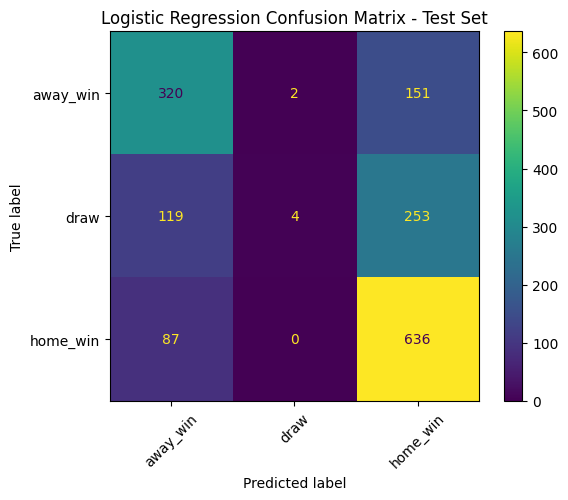

In [10]:
labels = log_reg_model.classes_

cm = confusion_matrix(y_test, test_preds, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix - Test Set")
plt.xticks(rotation=45)
plt.show()

# Exporting Logistic Regression Model

In [11]:
model_bundle = {
    "model": log_reg_model,
    "scaler": scaler,
    "features": features
}

joblib.dump(model_bundle, "../models/logistic_regression_model.joblib")

print("Model saved to ../models/logistic_regression_model.joblib")

Model saved to ../models/logistic_regression_model.joblib
